# 02 — EDA

Correlações entre indicadores e comportamento antes de cada recessão histórica
(1973, 1981, 1990, 2001, 2008, 2020).

In [1]:
import sys; sys.path.append('..')
from src.fetch_data import load_config
from src.features import build_features
import pandas as pd, matplotlib.pyplot as plt

config = load_config('../config.yaml')
raw = pd.read_parquet('../' + config['data']['raw_path'])
feats = build_features(raw, config)

c:\Users\pedro\Desktop\Projeto Machine Learning\notebooks\..\src\features.py:46: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out[f"{col}_yoy"] = out[col].pct_change(periods=12) * 100
c:\Users\pedro\Desktop\Projeto Machine Learning\notebooks\..\src\features.py:46: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out[f"{col}_yoy"] = out[col].pct_change(periods=12) * 100
c:\Users\pedro\Desktop\Projeto Machine Learning\notebooks\..\src\features.py:46: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading

In [2]:
# Matriz de correlação das features
cols = [c for c in feats.columns if c != 'recession']
feats[cols].corr()

,yield_10y3m,unemployment,fed_funds,consumer_sent,cpi_yoy,m2_yoy,industrial_yoy
yield_10y3m,1.000000,0.601307,-0.218169,-0.030674,-0.157105,0.149583,0.023553
unemployment,0.601307,1.000000,0.076750,-0.293215,0.067417,0.358330,-0.240207
fed_funds,-0.218169,0.076750,1.000000,-0.052873,0.694900,0.030714,0.114767
consumer_sent,-0.030674,-0.293215,-0.052873,1.000000,-0.422734,0.000996,0.386041
cpi_yoy,-0.157105,0.067417,0.694900,-0.422734,1.000000,0.097305,0.000894
m2_yoy,0.149583,0.358330,0.030714,0.000996,0.097305,1.000000,-0.066774
industrial_yoy,0.023553,-0.240207,0.114767,0.386041,0.000894,-0.066774,1.000000


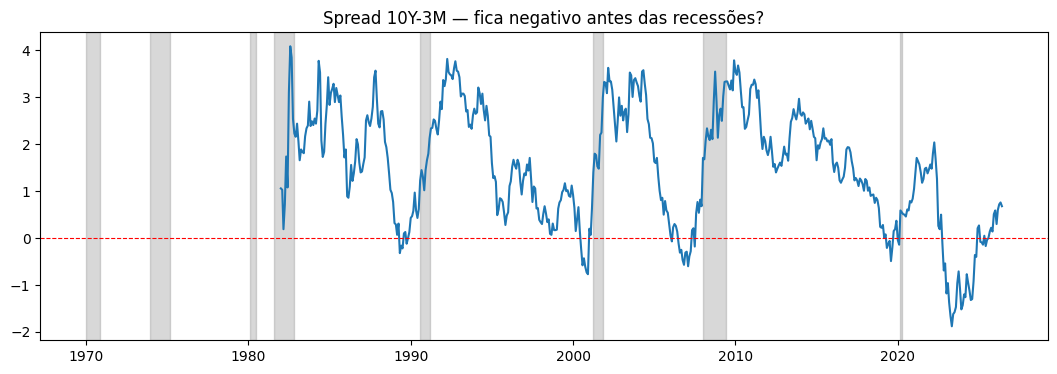

In [3]:
# Yield spread 10Y-3M ao longo do tempo (sombrear recessões)
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(feats.index, feats['yield_10y3m'])
ax.axhline(0, color='red', ls='--', lw=0.8)
ax.fill_between(raw.index, 0, 1, where=raw['recession']==1, transform=ax.get_xaxis_transform(), color='grey', alpha=0.3)
ax.set_title('Spread 10Y-3M — fica negativo antes das recessões?')
plt.show()